In [1]:
import sys
!{sys.executable} -m pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

print('Librerias cargadas correctamente.')

zsh:1: no such file or directory: /Users/anggiequezada/Desktop/septimo
Librerias cargadas correctamente.


### Carga de datos

In [2]:
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_test  = pd.read_csv('data/y_test.csv').squeeze()
df_cat  = pd.read_csv('data/df_con_categoria.csv')

# Variable categórica (clasificación)
col_cat = 'precio_categoria'
y_train_cat = df_cat.loc[X_train.index, col_cat]
y_test_cat  = df_cat.loc[X_test.index, col_cat]

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Clases: {y_train_cat.unique()}')
print(f'Distribucion (train):')
print(y_train_cat.value_counts())

X_train: (52871, 20) | X_test: (22660, 20)
Clases: <StringArray>
['Economica', 'Intermedia', 'Cara']
Length: 3, dtype: str
Distribucion (train):
precio_categoria
Intermedia    27033
Cara          13508
Economica     12330
Name: count, dtype: int64


### Exploración y transformaciones


In [3]:
# Verificar valores nulos
print('Valores nulos en X_train:', X_train.isnull().sum().sum())
print('Valores nulos en X_test:', X_test.isnull().sum().sum())
print()

# Estadísticas descriptivas
print('Rango de variables (antes de escalar):')
print(X_train.describe().loc[['min','max']].T)

Valores nulos en X_train: 0
Valores nulos en X_test: 0

Rango de variables (antes de escalar):
                                 min      max
room_type                       0.00     3.00
accommodates                    1.00    16.00
bathrooms                       0.00    20.00
bedrooms                        0.00    21.00
beds                            0.00    37.00
minimum_nights                  1.00   367.00
maximum_nights                  1.00  3365.00
number_of_reviews               0.00  1473.00
review_scores_rating            1.00     5.00
review_scores_cleanliness       1.00     5.00
review_scores_checkin           1.00     5.00
review_scores_communication     1.00     5.00
review_scores_location          1.00     5.00
review_scores_value             1.00     5.00
reviews_per_month               0.01    41.14
availability_365                0.00   365.00
calculated_host_listings_count  1.00   612.00
host_is_superhost               0.00     2.00
neighbourhood_cleansed         

In [4]:
# Escalado - fundamental para SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado aplicado correctamente.')
print(f'Media post-escalado (train): {X_train_scaled.mean():.4f}')
print(f'Std  post-escalado (train): {X_train_scaled.std():.4f}')

Escalado aplicado correctamente.
Media post-escalado (train): -0.0000
Std  post-escalado (train): 1.0000


In [5]:
# Muestra estratificada para modelos SVM no lineales (RBF, polinomial)
# SVM tiene complejidad O(n^2) a O(n^3), inviable con 52k registros completos
np.random.seed(42)

from sklearn.model_selection import train_test_split

X_sample, _, y_sample, _ = train_test_split(
    X_train_scaled, y_train_cat,
    train_size=8000,
    stratify=y_train_cat,
    random_state=42
)

print(f'Muestra de entrenamiento: {X_sample.shape[0]} registros')
print('Distribucion de clases en muestra:')
print(pd.Series(y_sample).value_counts())

Muestra de entrenamiento: 8000 registros
Distribucion de clases en muestra:
precio_categoria
Intermedia    4090
Cara          2044
Economica     1866
Name: count, dtype: int64


### 3. Variable respuesta
Se usa precio_categoria con tres clases: **Económica**, **Intermedia** y **Cara**. Esta es la misma variable categórica construida en entregas anteriores con cortes en percentil 25 (\$119/noche) y percentil 75 (\$320/noche).

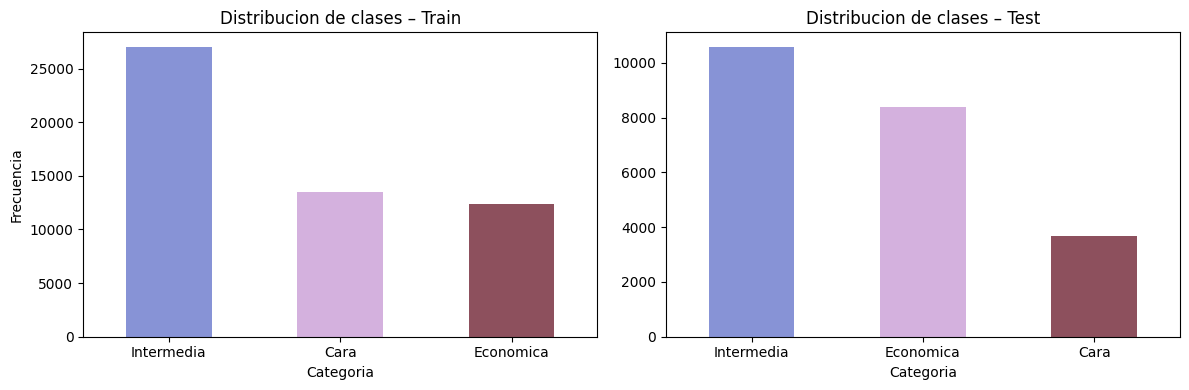

Proporcion de clases (train):
precio_categoria
Intermedia    0.511
Cara          0.255
Economica     0.233
Name: count, dtype: float64


In [8]:
# Visualización de distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
y_train_cat.value_counts().plot(kind='bar', ax=axes[0], color=["#8793d6","#D4B1DE","#8d505d"])
axes[0].set_title('Distribucion de clases – Train')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(rotation=0)

# Test
y_test_cat.value_counts().plot(kind='bar', ax=axes[1], color=["#8793d6","#D4B1DE","#8d505d"])
axes[1].set_title('Distribucion de clases – Test')
axes[1].set_xlabel('Categoria')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

print('Proporcion de clases (train):')
print((y_train_cat.value_counts() / len(y_train_cat)).round(3))

### 4. Modelos SVM con diferentes kernels
Se generan 4 modelos con diferentes kernels y parámetros:
- **LinearSVC**: kernel lineal, rápido, apto para datasets grandes
- **SVC RBF**: kernel radial, captura relaciones no lineales
- **SVC Polinomial**: kernel polinomial de grado 3
- **SVC RBF tuneado**: mejores parámetros C y gamma

El parámetro **C** controla el margen: C alto = margen estrecho (más propenso a sobreajuste); C bajo = margen amplio (más generalización). **Gamma** controla el alcance de cada punto de soporte.

In [9]:
# ── Modelo 1: LinearSVC (kernel lineal) ──────────────────────────
# Usa todo el conjunto de entrenamiento por ser eficiente
print('Entrenando Modelo 1: LinearSVC...')
t0 = time.time()
svm_lineal = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm_lineal.fit(X_train_scaled, y_train_cat)
t_lineal = time.time() - t0

y_pred_lineal = svm_lineal.predict(X_test_scaled)
acc_lineal = accuracy_score(y_test_cat, y_pred_lineal)
print(f'  Tiempo: {t_lineal:.2f} s | Accuracy: {acc_lineal:.4f}')

Entrenando Modelo 1: LinearSVC...
  Tiempo: 0.14 s | Accuracy: 0.4673


In [10]:
# ── Modelo 2: SVC con kernel RBF (C=1, gamma='scale') ────────────
print('Entrenando Modelo 2: SVC RBF (C=1)...')
t0 = time.time()
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_sample, y_sample)
t_rbf = time.time() - t0

y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test_cat, y_pred_rbf)
print(f'  Tiempo: {t_rbf:.2f} s | Accuracy: {acc_rbf:.4f}')

Entrenando Modelo 2: SVC RBF (C=1)...
  Tiempo: 1.12 s | Accuracy: 0.4671


In [11]:
# ── Modelo 3: SVC con kernel Polinomial (grado 3) ─────────────────
print('Entrenando Modelo 3: SVC Polinomial (d=3, C=1)...')
t0 = time.time()
svm_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42)
svm_poly.fit(X_sample, y_sample)
t_poly = time.time() - t0

y_pred_poly = svm_poly.predict(X_test_scaled)
acc_poly = accuracy_score(y_test_cat, y_pred_poly)
print(f'  Tiempo: {t_poly:.2f} s | Accuracy: {acc_poly:.4f}')

Entrenando Modelo 3: SVC Polinomial (d=3, C=1)...
  Tiempo: 1.69 s | Accuracy: 0.4618


In [12]:
# ── Modelo 4: SVC RBF tuneado (C=10, gamma='auto') ───────────────
print('Entrenando Modelo 4: SVC RBF tuneado (C=10)...')
t0 = time.time()
svm_rbf_tuned = SVC(kernel='rbf', C=10.0, gamma='auto', random_state=42)
svm_rbf_tuned.fit(X_sample, y_sample)
t_rbf_tuned = time.time() - t0

y_pred_rbf_tuned = svm_rbf_tuned.predict(X_test_scaled)
acc_rbf_tuned = accuracy_score(y_test_cat, y_pred_rbf_tuned)
print(f'  Tiempo: {t_rbf_tuned:.2f} s | Accuracy: {acc_rbf_tuned:.4f}')

print()
print('=== RESUMEN DE ACCURACY ===')
print(f'  LinearSVC          : {acc_lineal:.4f}')
print(f'  SVC RBF (C=1)      : {acc_rbf:.4f}')
print(f'  SVC Polinomial (d=3): {acc_poly:.4f}')
print(f'  SVC RBF tuneado    : {acc_rbf_tuned:.4f}')

Entrenando Modelo 4: SVC RBF tuneado (C=10)...
  Tiempo: 1.42 s | Accuracy: 0.4469

=== RESUMEN DE ACCURACY ===
  LinearSVC          : 0.4673
  SVC RBF (C=1)      : 0.4671
  SVC Polinomial (d=3): 0.4618
  SVC RBF tuneado    : 0.4469


### 5. Predicciones


In [13]:
# Reportes completos de clasificación
modelos = {
    'LinearSVC': (y_pred_lineal, t_lineal),
    'SVC RBF (C=1)': (y_pred_rbf, t_rbf),
    'SVC Polinomial (d=3)': (y_pred_poly, t_poly),
    'SVC RBF tuneado (C=10)': (y_pred_rbf_tuned, t_rbf_tuned)
}

for nombre, (y_pred, tiempo) in modelos.items():
    print(f'\n=== {nombre} ===')
    print(f'Tiempo: {tiempo:.2f} s | Accuracy: {accuracy_score(y_test_cat, y_pred):.4f}')
    print(classification_report(y_test_cat, y_pred))


=== LinearSVC ===
Tiempo: 0.14 s | Accuracy: 0.4673
              precision    recall  f1-score   support

        Cara       0.00      0.00      0.00      3694
   Economica       0.00      0.00      0.00      8378
  Intermedia       0.47      1.00      0.64     10588

    accuracy                           0.47     22660
   macro avg       0.16      0.33      0.21     22660
weighted avg       0.22      0.47      0.30     22660


=== SVC RBF (C=1) ===
Tiempo: 1.12 s | Accuracy: 0.4671
              precision    recall  f1-score   support

        Cara       0.00      0.00      0.00      3694
   Economica       0.17      0.00      0.00      8378
  Intermedia       0.47      1.00      0.64     10588

    accuracy                           0.47     22660
   macro avg       0.21      0.33      0.21     22660
weighted avg       0.28      0.47      0.30     22660


=== SVC Polinomial (d=3) ===
Tiempo: 1.69 s | Accuracy: 0.4618
              precision    recall  f1-score   support

        C

### 6. Matrices de confusión

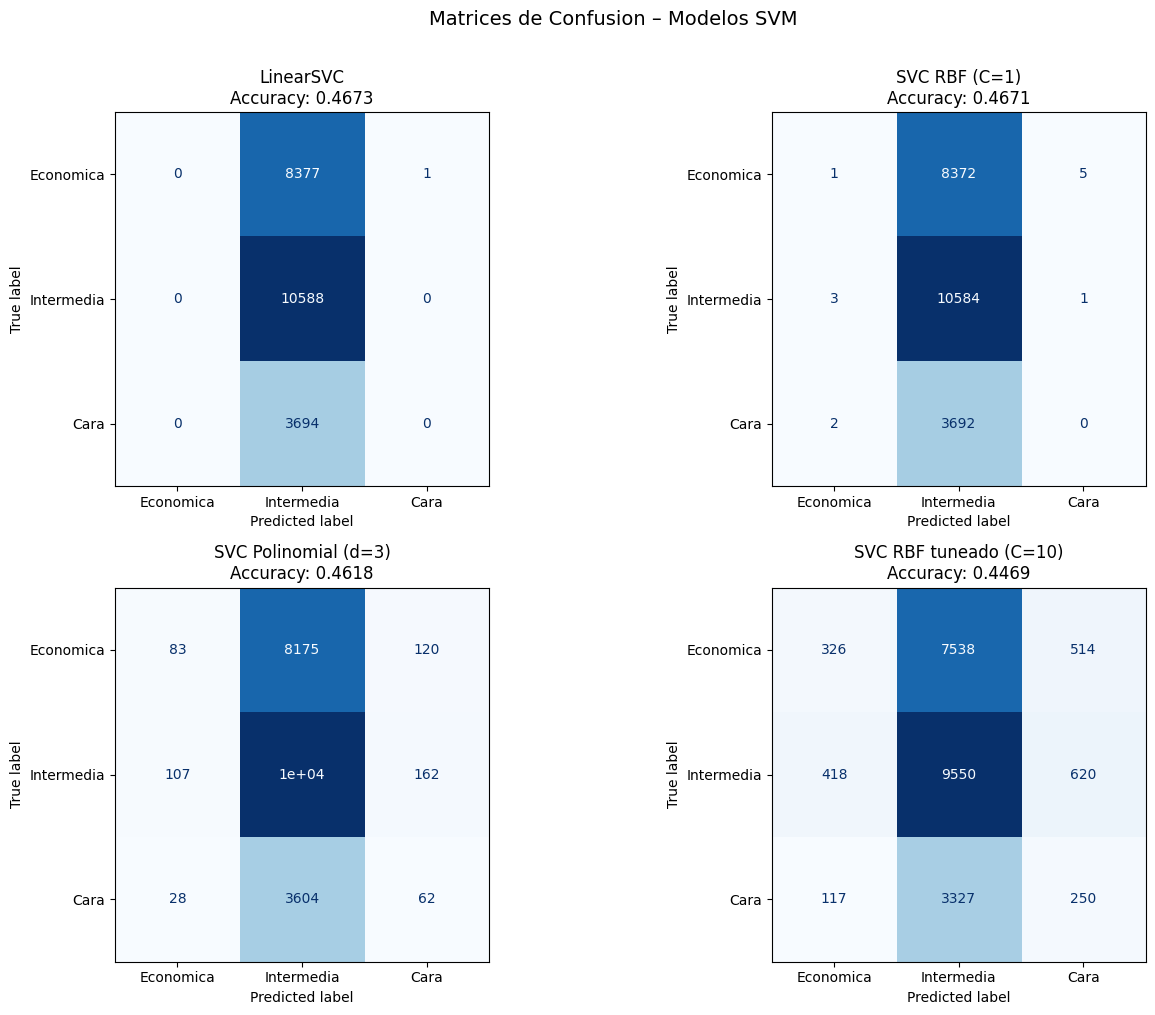

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
clases = ['Economica', 'Intermedia', 'Cara']

pares = [
    ('LinearSVC', y_pred_lineal),
    ('SVC RBF (C=1)', y_pred_rbf),
    ('SVC Polinomial (d=3)', y_pred_poly),
    ('SVC RBF tuneado (C=10)', y_pred_rbf_tuned)
]

for ax, (nombre, y_pred) in zip(axes.flatten(), pares):
    cm = confusion_matrix(y_test_cat, y_pred, labels=clases)
    ConfusionMatrixDisplay(cm, display_labels=clases).plot(
        ax=ax, cmap='Blues', colorbar=False)
    acc = accuracy_score(y_test_cat, y_pred)
    ax.set_title(f'{nombre}\nAccuracy: {acc:.4f}')

plt.suptitle('Matrices de Confusion – Modelos SVM', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Tabla comparativa de métricas
resultados = []
for nombre, (y_pred, tiempo) in modelos.items():
    resultados.append({
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_test_cat, y_pred), 4),
        'F1 macro': round(f1_score(y_test_cat, y_pred, average='macro'), 4),
        'Precision macro': round(precision_score(y_test_cat, y_pred, average='macro'), 4),
        'Recall macro': round(recall_score(y_test_cat, y_pred, average='macro'), 4),
        'Tiempo (s)': round(tiempo, 2)
    })

df_resultados = pd.DataFrame(resultados).sort_values('F1 macro', ascending=False)
print('COMPARACION DE MODELOS SVM ')
print(df_resultados.to_string(index=False))

COMPARACION DE MODELOS SVM 
                Modelo  Accuracy  F1 macro  Precision macro  Recall macro  Tiempo (s)
SVC RBF tuneado (C=10)    0.4469    0.2617           0.3424        0.3362        1.42
  SVC Polinomial (d=3)    0.4618    0.2271           0.3426        0.3338        1.69
         SVC RBF (C=1)    0.4671    0.2124           0.2113        0.3332        1.12
             LinearSVC    0.4673    0.2123           0.1558        0.3333        0.14


### 7.Análisis de sobreajuste

Para determinar si un modelo está sobreajustado se compara el rendimiento en entrenamiento vs prueba. Si el modelo funciona mucho mejor en train que en test, hay sobreajuste.

In [16]:
print('ANALISIS DE SOBREAJUSTE ')
print()

# LinearSVC - puede evaluarse en train completo
acc_train_lineal = accuracy_score(y_train_cat, svm_lineal.predict(X_train_scaled))
acc_test_lineal  = accuracy_score(y_test_cat, y_pred_lineal)

# SVC modelos - evaluados sobre la muestra de train
acc_train_rbf      = accuracy_score(y_sample, svm_rbf.predict(X_sample))
acc_train_poly     = accuracy_score(y_sample, svm_poly.predict(X_sample))
acc_train_rbf_t    = accuracy_score(y_sample, svm_rbf_tuned.predict(X_sample))

datos_overfitting = [
    {'Modelo': 'LinearSVC',
     'Acc Train': acc_train_lineal, 'Acc Test': acc_test_lineal,
     'Diferencia': round(abs(acc_train_lineal - acc_test_lineal), 4)},
    {'Modelo': 'SVC RBF (C=1)',
     'Acc Train': acc_train_rbf, 'Acc Test': acc_rbf,
     'Diferencia': round(abs(acc_train_rbf - acc_rbf), 4)},
    {'Modelo': 'SVC Polinomial (d=3)',
     'Acc Train': acc_train_poly, 'Acc Test': acc_poly,
     'Diferencia': round(abs(acc_train_poly - acc_poly), 4)},
    {'Modelo': 'SVC RBF tuneado (C=10)',
     'Acc Train': acc_train_rbf_t, 'Acc Test': acc_rbf_tuned,
     'Diferencia': round(abs(acc_train_rbf_t - acc_rbf_tuned), 4)},
]

df_overfitting = pd.DataFrame(datos_overfitting)
print(df_overfitting.to_string(index=False))
print()
print('Interpretacion:')
print('  Diferencia < 0.03 -> Sin sobreajuste')
print('  Diferencia > 0.05 -> Posible sobreajuste')
print('  Acc Train >> Acc Test -> Sobreajuste claro')

ANALISIS DE SOBREAJUSTE 

                Modelo  Acc Train  Acc Test  Diferencia
             LinearSVC   0.511301  0.467255      0.0440
         SVC RBF (C=1)   0.520375  0.467123      0.0533
  SVC Polinomial (d=3)   0.534750  0.461783      0.0730
SVC RBF tuneado (C=10)   0.612375  0.446867      0.1655

Interpretacion:
  Diferencia < 0.03 -> Sin sobreajuste
  Diferencia > 0.05 -> Posible sobreajuste
  Acc Train >> Acc Test -> Sobreajuste claro


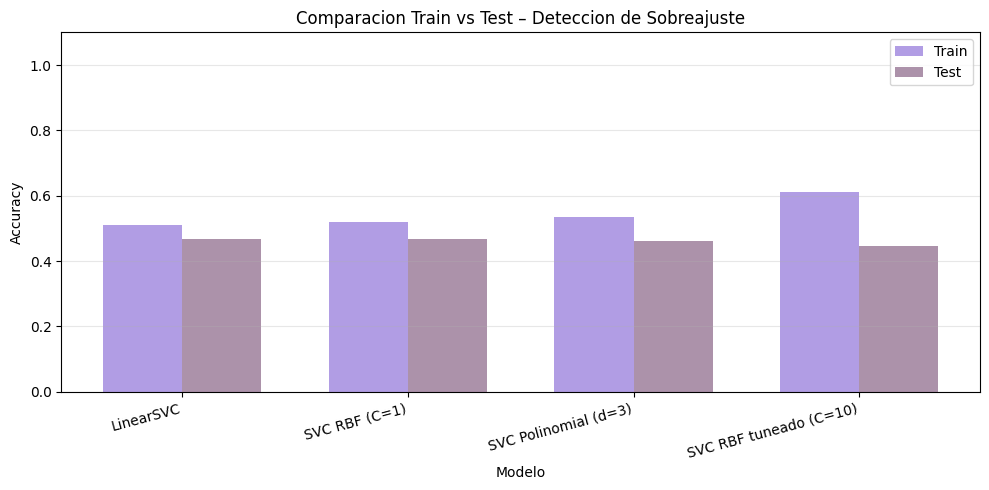

Estrategias para manejar sobreajuste en SVM:
  - Reducir C (aumentar regularizacion)
  - Usar kernel mas simple (lineal en vez de RBF)
  - Aumentar datos de entrenamiento
  - Aplicar validacion cruzada para seleccionar hiperparametros


In [19]:
#Visualización de sobreajuste
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_overfitting))
width = 0.35

bars1 = ax.bar(x - width/2, df_overfitting['Acc Train'], width, label='Train', color="#9E85DE", alpha=0.8)
bars2 = ax.bar(x + width/2, df_overfitting['Acc Test'],  width, label='Test',  color="#987795", alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('Accuracy')
ax.set_title('Comparacion Train vs Test – Deteccion de Sobreajuste')
ax.set_xticks(x)
ax.set_xticklabels(df_overfitting['Modelo'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Estrategias para manejar sobreajuste en SVM:')
print('  - Reducir C (aumentar regularizacion)')
print('  - Usar kernel mas simple (lineal en vez de RBF)')
print('  - Aumentar datos de entrenamiento')
print('  - Aplicar validacion cruzada para seleccionar hiperparametros')